In [2]:
exp_paths = [
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-11-03_3-2-1minIntervals/', # 660 cells, # 180 min
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-10-12_DoseResponse', # 800 cells, 40min
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-11-02_Sustained_1min', # 1350 cells, 120 min
'/Volumes/imaging.data/PertzLab/optoRTK_CedricZ/experimental_data/2025-09-04_RampReverse',
]

In [3]:
from notebooks.experiment.preprocessing import load_and_clean
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
from tqdm import tqdm

In [4]:
dfs = []
for ep in tqdm(exp_paths):    
    exp = Path(ep)
    p = exp / 'exp_data.parquet' 
    if not p.exists():
        raise FileNotFoundError(f"Data file not found: {p}")

    cell_sel_path = exp / 'cell_selection.csv'
    if cell_sel_path.exists():
        df_i = load_and_clean(p, cell_selection_csv=cell_sel_path)
    else:
        df_i = load_and_clean(p)
    dfs.append(df_i.copy())

df = pd.concat(dfs, ignore_index=True)
df.reset_index(drop=True, inplace=True)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:12<00:00,  3.06s/it]


# Experiments involved
Idea: create a multiindex for this df; Could prove ergonomic.
What might i want to index on?
- experiment
- 

In [5]:
df['ramp_pattern_name'].unique()

array(['3-2-1minIntervals', 'Single', 'Sustained', 'ramp1'], dtype=object)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497952 entries, 0 to 497951
Data columns (total 45 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   mean_intensity_C0_nuc             497952 non-null  float64
 1   mean_intensity_C1_nuc             497952 non-null  float64
 2   label                             497952 non-null  uint32 
 3   x                                 497952 non-null  float64
 4   y                                 497952 non-null  float64
 5   area                              497952 non-null  float64
 6   median_intensity_C0_nuc           497952 non-null  float64
 7   median_intensity_C1_nuc           497952 non-null  float64
 8   mean_intensity_C0_ring            497952 non-null  float64
 9   mean_intensity_C1_ring            497952 non-null  float64
 10  median_intensity_C0_ring          497952 non-null  float64
 11  median_intensity_C1_ring          497952 non-null  f

In [7]:
df['uid'].unique()
tdf = df[df['uid'] == '3-2-1minIntervals5_11']

In [8]:
tdf.info()

<class 'pandas.core.frame.DataFrame'>
Index: 210 entries, 0 to 1672
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   mean_intensity_C0_nuc             210 non-null    float64
 1   mean_intensity_C1_nuc             210 non-null    float64
 2   label                             210 non-null    uint32 
 3   x                                 210 non-null    float64
 4   y                                 210 non-null    float64
 5   area                              210 non-null    float64
 6   median_intensity_C0_nuc           210 non-null    float64
 7   median_intensity_C1_nuc           210 non-null    float64
 8   mean_intensity_C0_ring            210 non-null    float64
 9   mean_intensity_C1_ring            210 non-null    float64
 10  median_intensity_C0_ring          210 non-null    float64
 11  median_intensity_C1_ring          210 non-null    float64
 12  cnr         

In [9]:
tdf['channels'].astype('string').unique()

<StringArray>
["[{'device_name': None, 'exposure': 300, 'group': None, 'name': 'miRFP', 'power': None, 'property_name': None}\n {'device_name': None, 'exposure': 200, 'group': None, 'name': 'mScarlet3', 'power': None, 'property_name': None}]"]
Length: 1, dtype: string

In [10]:
df['stim_exposure'].unique()

array([   0.,   50.,  100.,  250.,  500.,   25.,   75.,  150.,  200.,
       1000.,  300.,  400.,   nan,  700.,  695.,  690.,  685.,  680.,
        675.,  670.,  665.,  660.,  655.,  650.,  645.,  640.,  635.,
        630.,  625.,  620.,  615.,  610.,  605.,  600.,  595.,  590.,
        585.,  580.,  575.,  570.,  565.,  560.,  555.,  550.,  545.,
        540.,  535.,  530.,  525.,  520.,  515.,  510.,  505.,  495.,
        490.,  485.,  480.,  475.,  470.,  465.,  460.,  455.,  450.,
        445.,  440.,  435.,  430.,  425.,  420.,  415.,  410.,  405.,
        395.,  390.,  385.,  380.,  375.,  370.,  365.,  360.,  355.,
        350.,  345.,  340.,  335.,  330.,  325.,  320.,  315.,  310.,
        305.,  295.,  290.,  285.,  280.,  275.,  270.,  265.,  260.,
        255.,  245.,  240.,  235.,  230.,  225.,  220.,  215.,  210.,
        205.,  195.,  190.,  185.,  180.,  175.,  170.,  165.,  160.,
        155.,  145.,  140.,  135.,  130.,  125.,  120.,  115.,  110.,
        105.,   95.,

<Axes: >

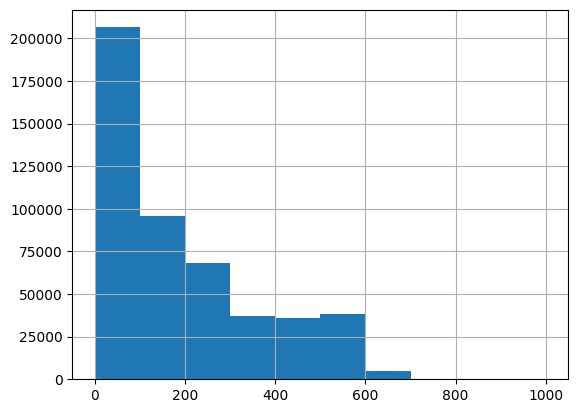

In [11]:
df['stim_exposure'].hist()

In [12]:
df[df['stim_power'] == 3]['ramp_pattern_name'].unique()

array(['ramp1'], dtype=object)

In [13]:
df['stim_exposure_list'].astype('string').unique()

<StringArray>
[                                                                                                                                                                                                                                             '[50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50\n 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50\n 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50\n 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50\n 50 50 50 50 50 50 50 50 50 50 50 50 50 50 50]',
                                                                                                                                                                                                                                                                                                                                                                                                                  

<Axes: >

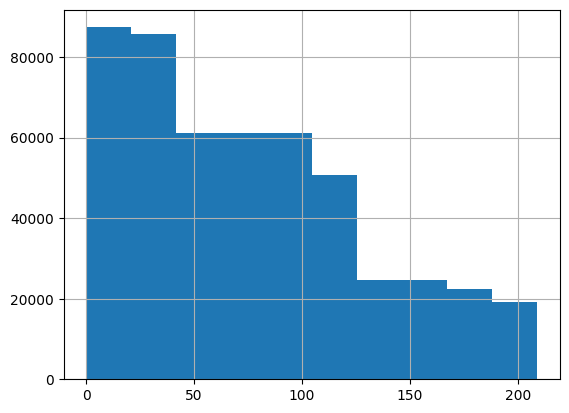

In [14]:
df['timestep'].hist() # prev 'time'; but that's something else; TODO: what is 'time'

In [15]:
df['timestep']

0           0
1           0
2           0
3           0
4           0
         ... 
497947    179
497948    179
497949    179
497950    179
497951    179
Name: timestep, Length: 497952, dtype: uint32

Is this not suspicious? Why does it look like this? - nevermind, 'time' column is something else, I care about timestep.

In [16]:
pd.isna(df['stim_exposure']).count()

np.int64(497952)

Ohhhh this shit has Nans in it. That's not good :///

# Investigating the intervals df

In [17]:
idf = df[df['ramp_pattern_name'] == '3-2-1minIntervals']
idf['area']

0         436.0
1         265.0
2         654.0
3         283.0
4         415.0
          ...  
193007    992.0
193008    682.0
193009    792.0
193010    224.0
193011    683.0
Name: area, Length: 193012, dtype: float64

In [18]:
((idf['stim_exposure'] == 500).sum(),
(idf['stim_exposure'] ==100).sum(),
(idf['stim_exposure'] ==250).sum())

(np.int64(33253), np.int64(32740), np.int64(32384))

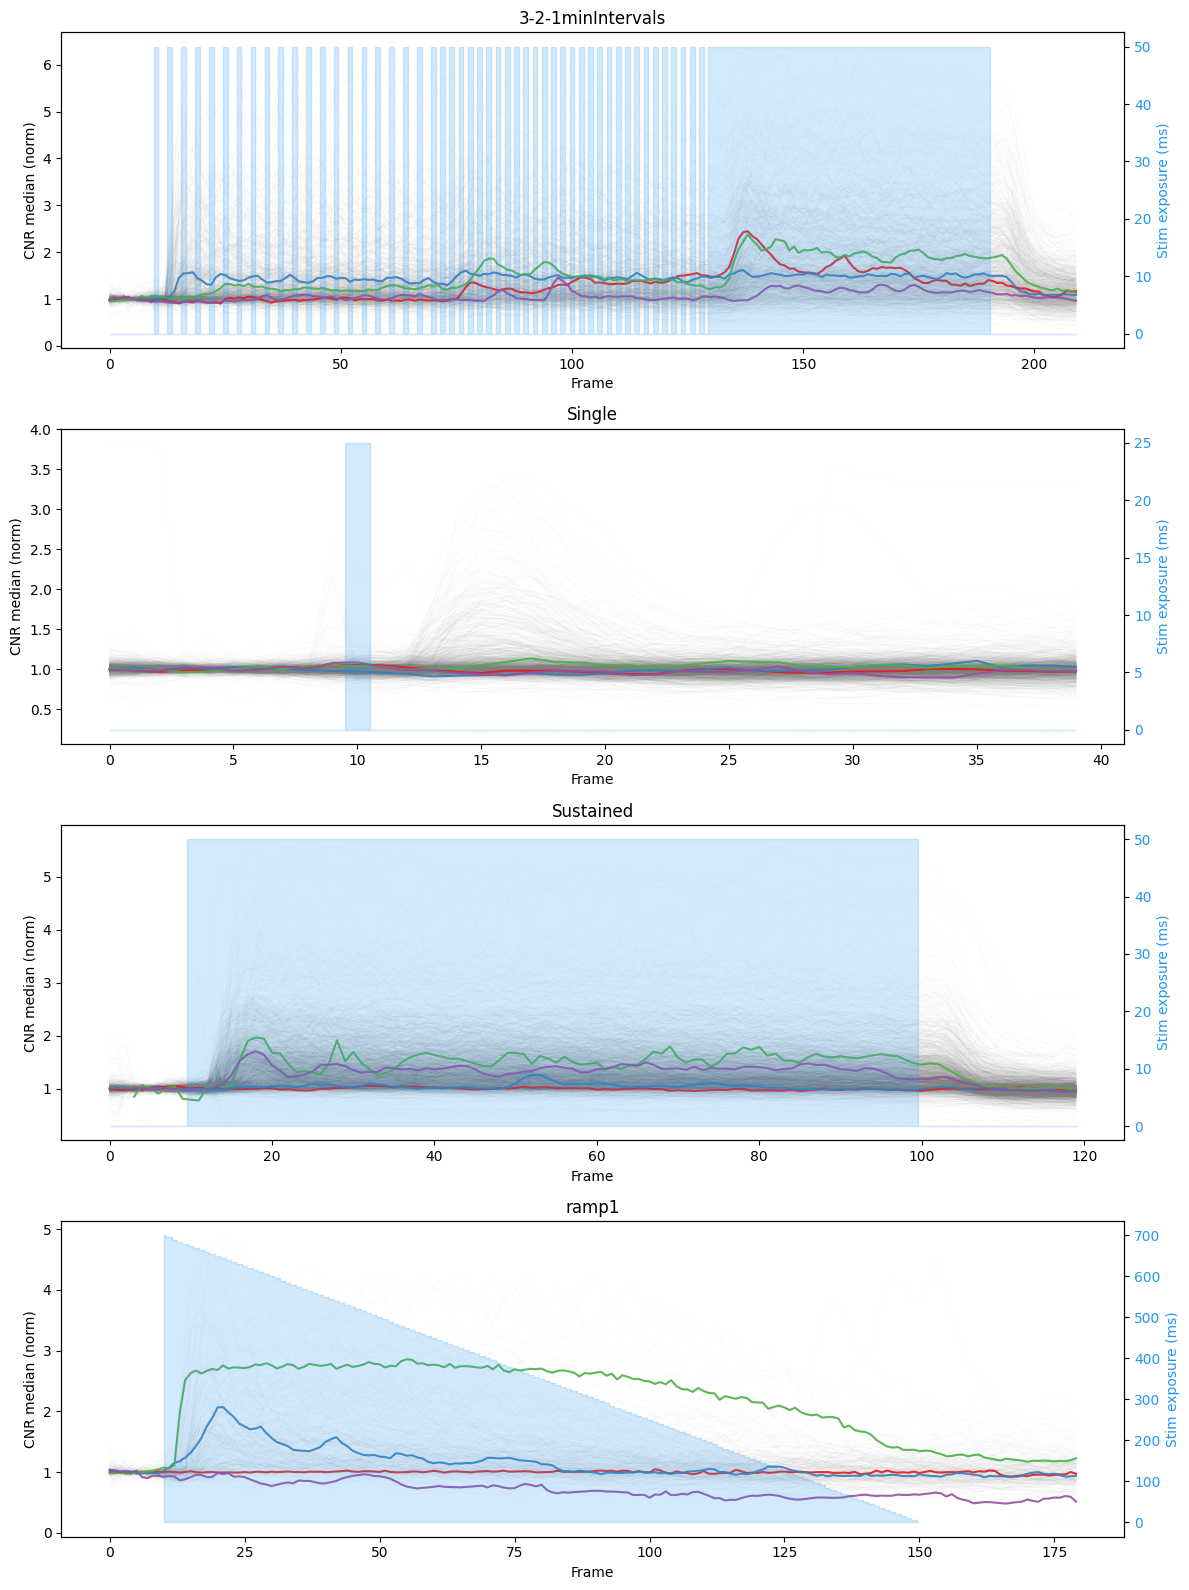

In [19]:
experiments = df['ramp_pattern_name'].unique()
n_exp = len(experiments)

fig, axes = plt.subplots(n_exp, 1, figsize=(12, 4 * n_exp), sharex=False)
if n_exp == 1:
    axes = [axes]

np.random.seed(42)

for ax, exp_name in zip(axes, experiments):
    edf = df[df['ramp_pattern_name'] == exp_name]
    uids = edf['uid'].unique()

    # Plot all trajectories with low alpha
    for uid in uids:
        cell = edf[edf['uid'] == uid].sort_values('frame')
        ax.plot(cell['frame'], cell['cnr_median_norm'], color='grey', alpha=0.03, linewidth=0.5)

    # Sample 4 cells and plot with high alpha
    sampled = np.random.choice(uids, size=min(4, len(uids)), replace=False)
    colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3']
    for uid, c in zip(sampled, colors):
        cell = edf[edf['uid'] == uid].sort_values('frame')
        ax.plot(cell['frame'], cell['cnr_median_norm'], color=c, alpha=0.9, linewidth=1.5)

    # Plot light activation on twin axis
    # Use one representative cell's stim_exposure (same across cells at each frame)
    stim = edf.groupby('frame')['stim_exposure'].first().sort_index()
    ax2 = ax.twinx()
    ax2.fill_between(stim.index, stim.values, color='#2196F3', alpha=0.2, step='mid')
    ax2.set_ylabel('Stim exposure (ms)', color='#2196F3')
    ax2.tick_params(axis='y', labelcolor='#2196F3')

    ax.set_title(exp_name)
    ax.set_ylabel('CNR median (norm)')
    ax.set_xlabel('Frame')

plt.tight_layout()
plt.show()

<Axes: >

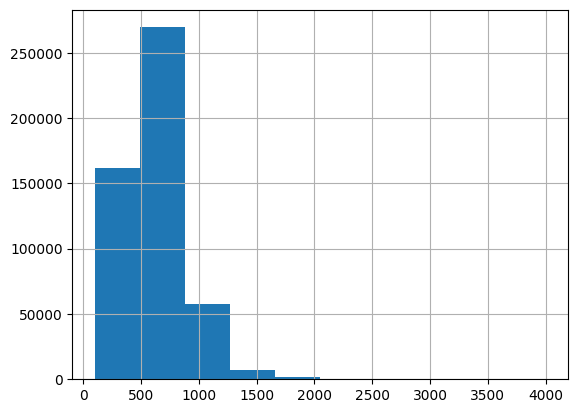

In [59]:
df['area'].hist()

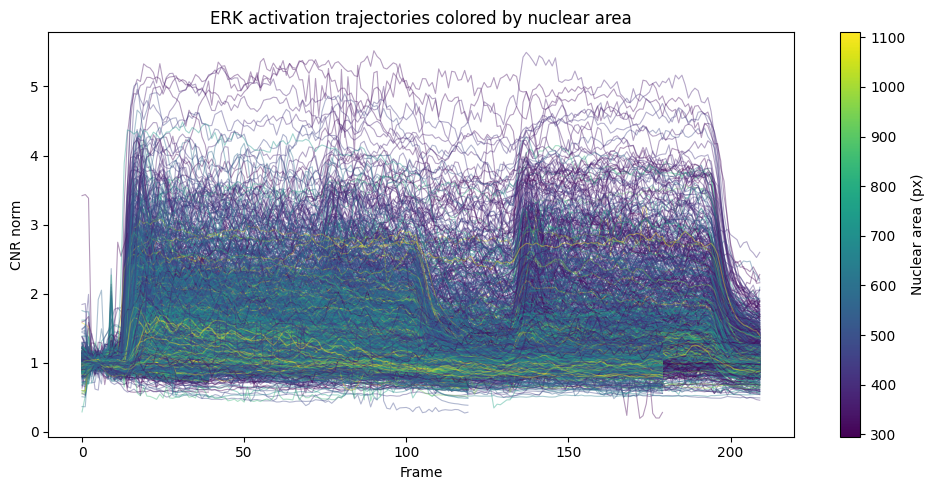

In [60]:
import matplotlib.pyplot as plt                                                                                                                                                     
import matplotlib.cm as cm
import matplotlib.colors as mcolors                                                                                                                                                 
import numpy as np
fig, ax = plt.subplots(figsize=(10, 5))

# per-cell median area for coloring
cell_area = df.groupby("uid")["area"].median()
norm = mcolors.Normalize(vmin=cell_area.quantile(0.05), vmax=cell_area.quantile(0.95))
cmap = cm.viridis

for uid, grp in df.groupby("uid"):
    grp = grp.sort_values("frame")
    ax.plot(grp["frame"], grp["cnr_norm"], color=cmap(norm(cell_area[uid])), alpha=0.4, lw=0.8)

fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="Nuclear area (px)")
ax.set_xlabel("Frame")
ax.set_ylabel("CNR norm")
ax.set_title("ERK activation trajectories colored by nuclear area")
plt.tight_layout()
plt.show()

/var/folders/92/3gzjc7p14mvb4pqkx2ryk0680000gn/T/ipykernel_35347/3245523051.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


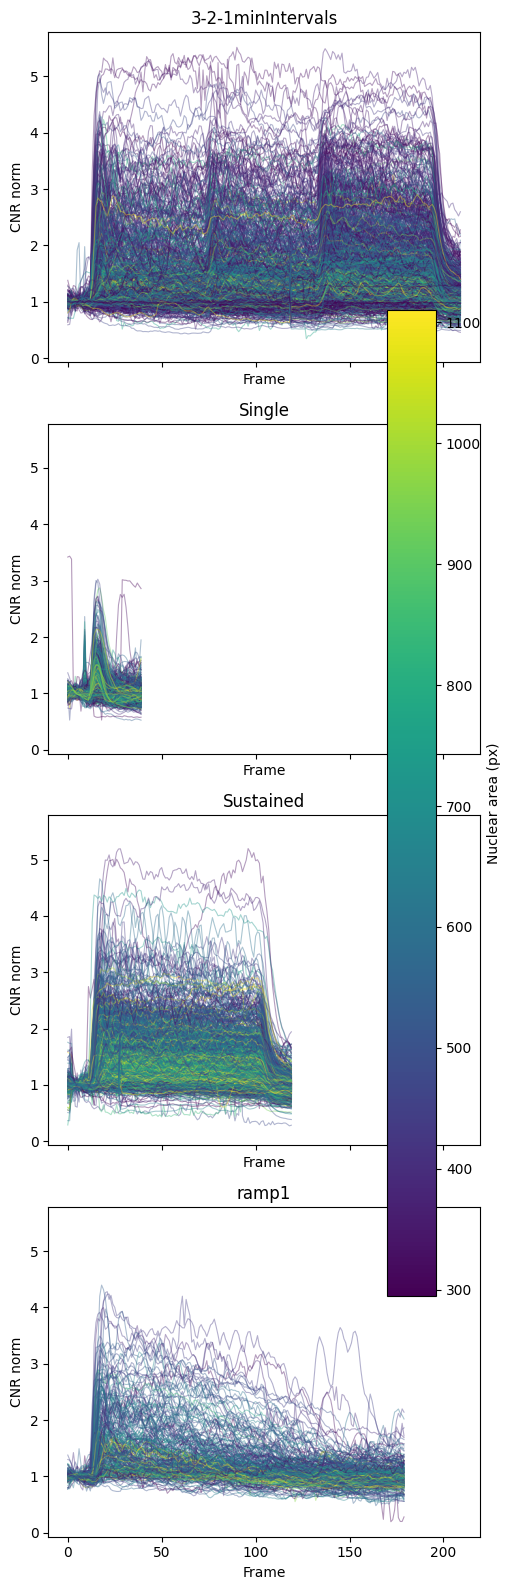

In [62]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

fig_cols = 1
patterns = df["ramp_pattern_name"].unique()
fig_rows = -(-len(patterns) // fig_cols)  # ceil division

cell_area = df.groupby("uid")["area"].median()
norm = mcolors.Normalize(vmin=cell_area.quantile(0.05), vmax=cell_area.quantile(0.95))
cmap = cm.viridis

fig, axes = plt.subplots(fig_rows, fig_cols, figsize=(5 * fig_cols, 4 * fig_rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, pattern in enumerate(sorted(patterns)):
    ax = axes[i]
    sub = df[df["ramp_pattern_name"] == pattern]
    for uid, grp in sub.groupby("uid"):
        grp = grp.sort_values("frame")
        ax.plot(grp["frame"], grp["cnr_norm"], color=cmap(norm(cell_area[uid])), alpha=0.4, lw=0.8)
    ax.set_title(pattern)
    ax.set_xlabel("Frame")
    ax.set_ylabel("CNR norm")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label="Nuclear area (px)", shrink=0.8)
plt.tight_layout()
plt.show()

/var/folders/92/3gzjc7p14mvb4pqkx2ryk0680000gn/T/ipykernel_35347/927098041.py:28: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


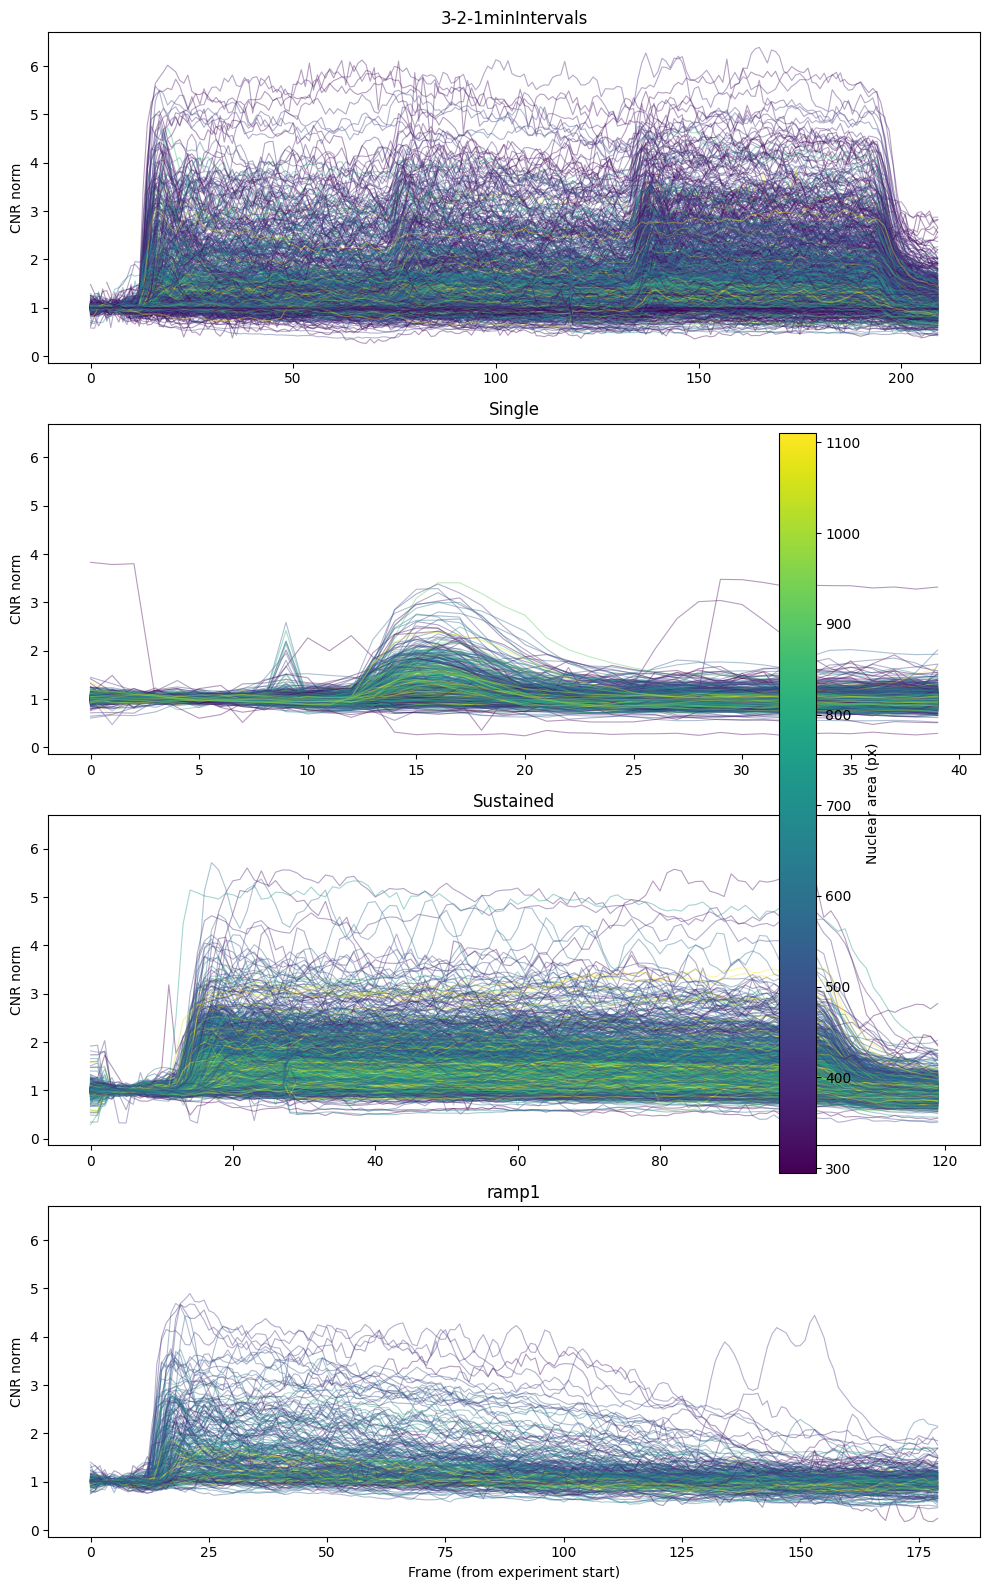

In [117]:

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

patterns = sorted(df["ramp_pattern_name"].unique())
n = len(patterns)

cell_area = df.groupby("uid")["area"].median()
norm = mcolors.Normalize(vmin=cell_area.quantile(0.05), vmax=cell_area.quantile(0.95))
cmap = cm.viridis

fig, axes = plt.subplots(n, 1, figsize=(10, 4 * n), sharey=True)
if n == 1:
    axes = [axes]

for ax, pattern in zip(axes, patterns):
    sub = df[df["ramp_pattern_name"] == pattern]
    frame_min = sub["frame"].min()
    for uid, grp in sub.groupby("uid"):
        grp = grp.sort_values("frame")
        ax.plot(grp["frame"] - frame_min, grp["cnr_median_norm"], color=cmap(norm(cell_area[uid])), alpha=0.4, lw=0.8)
    ax.set_title(pattern)
    ax.set_ylabel("CNR norm")

axes[-1].set_xlabel("Frame (from experiment start)")
fig.colorbar(cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, label="Nuclear area (px)", location="right",
shrink=0.6)
plt.tight_layout()
plt.show()

In [65]:
df[df['ramp_pattern_name'] == '3-2-1minIntervals']['uid'].unique()

<StringArray>
[ '3-2-1minIntervals5_11',  '3-2-1minIntervals5_20',  '3-2-1minIntervals5_21',
  '3-2-1minIntervals5_24',  '3-2-1minIntervals5_25',  '3-2-1minIntervals5_26',
  '3-2-1minIntervals5_32',  '3-2-1minIntervals5_55',   '3-2-1minIntervals6_4',
   '3-2-1minIntervals6_9',
 ...
 '3-2-1minIntervals54_58', '3-2-1minIntervals54_59', '3-2-1minIntervals54_60',
 '3-2-1minIntervals54_62', '3-2-1minIntervals54_64', '3-2-1minIntervals54_65',
 '3-2-1minIntervals54_67', '3-2-1minIntervals54_68', '3-2-1minIntervals54_70',
 '3-2-1minIntervals54_72']
Length: 920, dtype: string

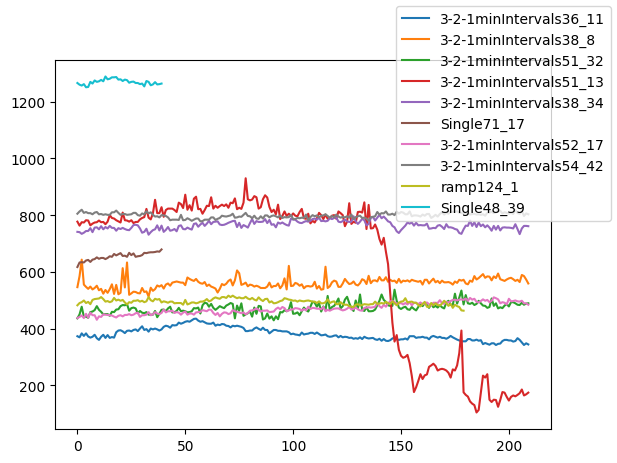

In [106]:
fig, ax = plt.subplots()

cells = df['uid'].sample(10)
for c in cells:
  r = df[df['uid'] == c]
  ax.plot(r['frame'], r['area'], label=c)
fig.legend()



array([  0., 500.], dtype=float32)

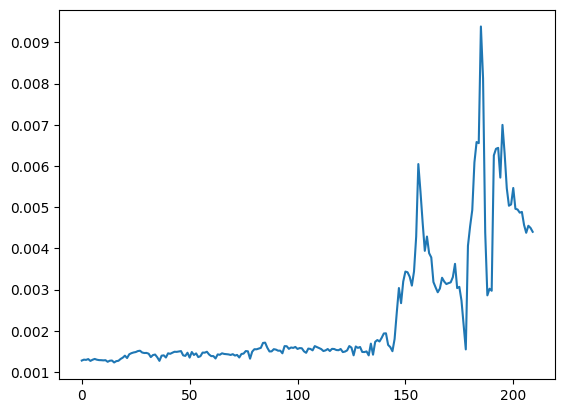

In [116]:
INTERESTING_ONE = 3

cid = cells.iloc[INTERESTING_ONE]
int_cell=df[df['uid'] == cid]
plt.plot(int_cell['frame'], int_cell['cnr_norm'] / int_cell['area'])
int_cell['stim_exposure'].unique()

In [ ]:
#df.to_parquet('./dataset.parquet')